# Bag of words

Amaç:
* Metin temsili: metin listesi -> sayısal vektör
* sklearn CountVectorizer: kelimelerin kaç defa geçtiğini sayar ve vertör temsiline dönüştürür.
Sonuç:
* Kelime kümesi
* Her metin listesi sayısal vektörler ile temsil edilecek.

## Küçük veri setinde mantığı

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# örnek metinlerden oluşan küçük bir veri seti oluştur

dokumanlar = [
    "kedi bahçede", # 1. cümle
    "Kedi evde" # 2. cümle
]

In [ ]:
# count vectorizer nesnesini oluştur

kelime_sayac = CountVectorizer()

In [ ]:
# dökümanlar -> sayısal vektör (bag of words)

dokuman_vektorleri = kelime_sayac.fit_transform(dokumanlar)
dokuman_vektorleri

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4 stored elements and shape (2, 3)>

In [ ]:
# count vectorizer tarafından bulunan kelime listesi oluşturma ve print
kelime_kumesi = kelime_sayac.get_feature_names_out()
print(f"kelime kümesi: {kelime_kumesi}") # kedi ve Kedi iki defa tekrarlanmadı! Her kelime bir vektör olarak alındı.

kelime kümesi: ['bahçede' 'evde' 'kedi']


In [ ]:
# vektör temsiline bakalım
vektor_temsili = dokuman_vektorleri.toarray()
print(f"vektör temsili: \n {vektor_temsili}") # Kelime vektör dizesine göre cümlede varsa 1 yoksa 0
# buradaki vektörler cümlelere ait.

vektör temsili: 
 [[1 0 1]
 [0 1 1]]


## Gerçek veri seti ile
Amaç:
* IMDB film yorumları içeren veri seti ile bag of words
* csv dosyasından veriyi oku (IMDB Dataset.csv)
* Text cleaning (küçük büyük harf çevirme, rakam ve özel karakterlerden kurtulma)
* Metinler -> sayısal vektörler
* Kelime frekanslarını hesaplama
    * En sık geçen 5 kelimeyi listele

In [ ]:
# gerekli kütüphanelerin içeri aktarılması
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import re # regEx
from collections import Counter

In [ ]:
# read csv
import kagglehub
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews") + "/IMDB Dataset.csv"
df = pd.read_csv(path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


In [ ]:
df.head(10)

In [ ]:
yorumlar = df["review"]
yorumlar.head(10)

In [ ]:
etiketler = df["sentiment"]
etiketler.head()

In [ ]:
import nltk
from nltk.corpus import stopwords

# Hatanın çözümü burası:
nltk.download('stopwords')
nltk.download('punkt') # Bazı durumlarda kelime bölme için gerekebilir

In [ ]:
# metin temizleme
def metin_temizleme(metin):
  # tüm harfleri küçük harfe çevir
  metin = metin.lower()

  """
  re.sub(pattern, repl, string): Bu fonksiyon, string içinde pattern (kalıp)
  ile eşleşen her şeyi repl (yeni değer) ile değiştirir.

  r"...": "Raw string" anlamına gelir. Ters eğik çizgilerin "\" Python tarafından
  özel bir karakter olarak yorumlanmasını engeller, doğrudan regex motoruna gönderir.

  """
  # rakamları kaldır
  metin = re.sub(r"\d+","", metin) #rakamları bul, boşluk ile değiş, metin'e uygula

  # özel karakterleri kaldır
  metin = re.sub(r"[^\w\s]", "", metin) # ya bir alfanümerik (w) ya bir boşluk (s)
  # ^olumsuzlama eki -> [] içindeyse

  # çok kısa kelimeleri kaldır (2 den az örn: ve)
  metin = " ".join([kelime for kelime in metin.split() if len(kelime) > 2])

  # stop words çıkarma
  stop_words = set(stopwords.words('english'))
  metin = " ".join([kelime for kelime in metin.split() if kelime not in stop_words])

  return metin


In [ ]:
# yorumları temizleme işlemi uygula
temizlenmis_yorumlar = [metin_temizleme(y) for y in yorumlar]

In [ ]:
temizlenmis_yorumlar[0]

In [ ]:
# bow
bow_modeli = CountVectorizer()
yorum_vektorleri = bow_modeli.fit_transform(temizlenmis_yorumlar)
kelime_kumesi = bow_modeli.get_feature_names_out()

In [ ]:
kelime_kumesi
# başka diller ve _ bu işaretler kalmış

In [ ]:
vektor_temsili = yorum_vektorleri.toarray()
vektor_temsili

In [ ]:
# her kelime toplam kaç adet geçiyor
kelime_sayilari = yorum_vektorleri.sum(axis = 0).A1

In [ ]:
# kelimeler ve frekanslar bir sözlükte
kelime_frekansi = dict(zip(kelime_kumesi, kelime_sayilari))
top_5 = Counter(kelime_frekansi).most_common(5)
top_5

## TF-IDF
Örnek cümleler üzerinden TF-IDF uygulayarak cümleleri vektörleştirmek.
****
Adımlar:
1. Küçük bir belge oluştur.
2. TF-IDF ile belge -> sayısal vektör
3. Kelime kümesi oluşturma
4. Belgelerin TF-IDF vektör temsillerini elde etme
5. Tüm belgeler için kelimelerin ortalama TF-IDF değerlerini hesaplama

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# örnek belge
belgeler = [
    "köpek çok tatlı bir hayvandır",
    "inekler süt üretirler",
    "İnekler süt üretirler"
]

In [ ]:
tfidf_modeli = TfidfVectorizer()

In [ ]:
# belgeler -> sayısal vektör
belge_vektorleri = tfidf_modeli.fit_transform(belgeler)

In [ ]:
# vocabulary
kelime_kumesi = tfidf_modeli.get_feature_names_out()

In [ ]:
# belgelerin tf idf değerlerini numpy dönüştür
vektor_temsili = belge_vektorleri.toarray()

In [ ]:
vektor_temsili

In [ ]:
# okunabilir hale getir
df_tf_idf = pd.DataFrame(vektor_temsili, columns=kelime_kumesi)
df_tf_idf

In [ ]:
# her kelimenin belgeler arasındaki tf idf değerleri
ortalama_tfidf = df_tf_idf.mean(axis=0)
ortalama_tfidf # kullanım sıklığı

In [ ]:
# imdb veri seti için
tf_idf_imdb_vek = tfidf_modeli.fit_transform(temizlenmis_yorumlar)

In [ ]:
kelime_imdb = tfidf_modeli.get_feature_names_out()
kelime_imdb

In [ ]:
vek_tem_imdb = tf_idf_imdb_vek.toarray()
vek_tem_imdb

In [ ]:
df_tf_idf_imdb = pd.DataFrame(vek_tem_imdb, columns=kelime_imdb)
ortalama_tfidf = df_tf_idf_imdb.mean(axis=0)


In [ ]:
ortalama_tfidf.sort_values(ascending=False) # kullanım sıklığı

## Word Embedding (Kelime Gömme)
* word2vec : google
* fasttext : meta

****
Adımlar:

1.   Örnek cümle veri seti
2. preprocessing: cümle -> token
3. word2vec ve fasttext modelleri eğitme
4. kelime vectorleri 2d görselleştirilir

In [ ]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.8 MB/s eta 0:00:00


In [ ]:
# gerekli kütüphaneler
import pandas as pd
import numpy as np
from gensim.models import Word2Vec, FastText
from gensim.utils import simple_preprocess

In [ ]:
# örnek veri seti
cumleler = [
    "köpek bağımsız bir hayvandır.",
    "köpekler evcil hayvanlardır",
    "kediler genellikle bağımsız hayvanlardır",
    "köpekler dost canlısıdır",
    "Türkiye'nin başkenti Ankara'dır.",
    "Gaziantep'in yemekleri çok güzeldir",
    "Karadeniz insanı sinirlidir",
    "Akdenizde insanlar siesta yapmayı sever"
]

In [ ]:
# cümleleri tokenize et
tokenize_cumleler = [simple_preprocess(c) for c in cumleler]
tokenize_cumleler

[['köpek', 'bağımsız', 'bir', 'hayvandır'],
 ['köpekler', 'evcil', 'hayvanlardır'],
 ['kediler', 'genellikle', 'bağımsız', 'hayvanlardır'],
 ['köpekler', 'dost', 'canlısıdır'],
 ['türkiye', 'nin', 'başkenti', 'ankara', 'dır'],
 ['gaziantep', 'in', 'yemekleri', 'çok', 'güzeldir'],
 ['karadeniz', 'insanı', 'sinirlidir'],
 ['akdenizde', 'insanlar', 'siesta', 'yapmayı', 'sever']]

In [ ]:
# word2vec

word2vec = Word2Vec(
    sentences = tokenize_cumleler,
    vector_size=2, # doğrudan 2d vektör
    window = 5, # bağlamı öğrenirken etrafındaki kaç kelimeye bakmalı
    min_count = 1, # bir kelimenin modele dahi olabilmesi için en az kaç defa geçmeli
    sg = 0 # 0: CBOM(continuous bag of words) kelimenin bağlamından kelime tahmini
    # 1: skip gram kelimeden bağlamdaki kelimeleri tahmin eder

)

In [ ]:
# FastText
fasttext = FastText(
    sentences = tokenize_cumleler,
    vector_size=2,
    window = 5,
    min_count=1,
    sg=0
)

In [ ]:
import matplotlib.pyplot as plt

def plot_word_embedings(model, baslik):
  kelime_vektor = model.wv # word vektör
  kelimeler = list(kelime_vektor.index_to_key)
  vektorler = [kelime_vektor[w] for w in kelimeler]

  plt.figure(figsize = (10,5))
  plt.scatter([v[0] for v in vektorler], [v[1] for v in vektorler])

  for i, kelime in enumerate(kelimeler):
    plt.text(vektorler[i][0], vektorler[i][1], kelime, fontsize = 12)

  plt.title(baslik)
  plt.xlabel("Bileşen 1")
  plt.ylabel("Bileşen 2")
  plt.show()

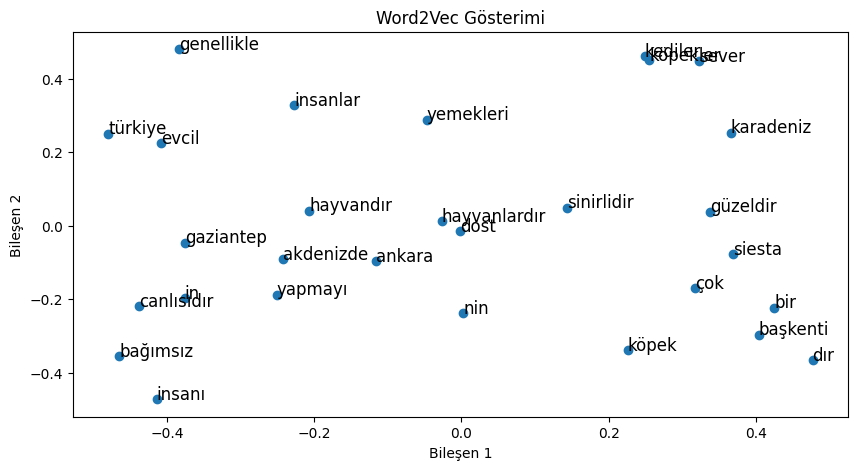

In [ ]:
plot_word_embedings(word2vec, "Word2Vec Gösterimi")

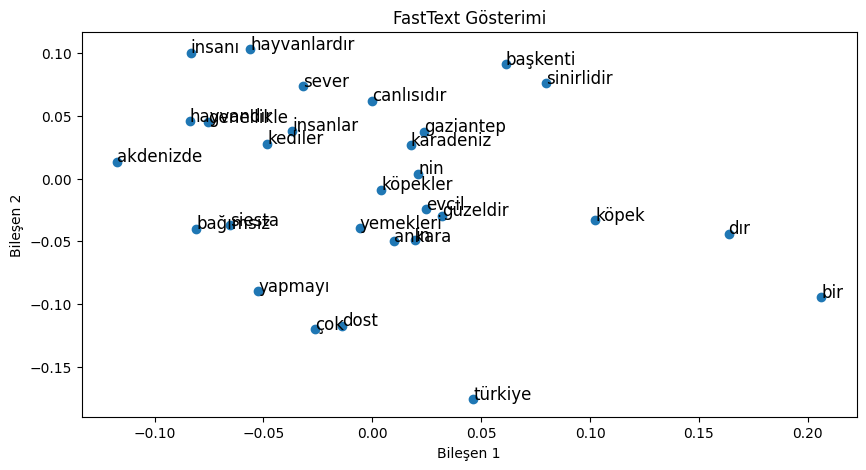

In [ ]:
plot_word_embedings(fasttext, "FastText Gösterimi")

## IMDB veri seti ile word embedding
IMDB film yorumları üzerinden FastText tabanlı kelime vektörleri üretme ve 2d görselleştirme
****
Adımlar:
1. Veri seti yükleme
2. Metinleri temizleme (küçük harf dönüşümü, özel karakterler, kısa kelimelerin kaldırılması, stopwords silme)
3. tokenizasyon
4. FastText model eğitimi
5. 2d görselleştirme

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from gensim.models import FastText
from gensim.utils import simple_preprocess

In [ ]:
# stopwords indirme
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# veri seti yükleme
import kagglehub
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
path = path +"/IMDB Dataset.csv"
df = pd.read_csv(path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
yorumlar = df['review']

In [ ]:
# metin temizleme
def metin_temizle(metin):
  metin = metin.lower()
  metin = re.sub(r"\d+", "", metin) # rakamları kaldırma
  metin = re.sub (r"\w\s", "", metin) # noktalama ve özel karakterleri kaldır
  kelimeler = metin.split()
  #stop wprds kaldır
  kelimeler = [k for k in kelimeler if k not in stop_words]

  # kısa kelimeleri çıkart
  kelimeler = [k for k in kelimeler if len(k)>2]

  return " ".join(kelimeler)

In [ ]:
# yorumları temizle
temiz_yorumlar = [metin_temizle(y) for y in yorumlar]

In [ ]:
#tokonizasyon
tokenize_yorumlar = [simple_preprocess(y) for y in temiz_yorumlar]

In [ ]:
# fastText
fasttext_model = FastText(
    sentences = tokenize_yorumlar,
    vector_size = 3,
    window = 5,
    min_count = 3,
    sg = 1
)

In [ ]:
# kelime vektörlerini al
kelime_vektorleri = fasttext_model.wv
kelimeler = list(kelime_vektorleri.index_to_key)[:150]
vektorler = [kelime_vektorleri[w] for w in kelimeler]


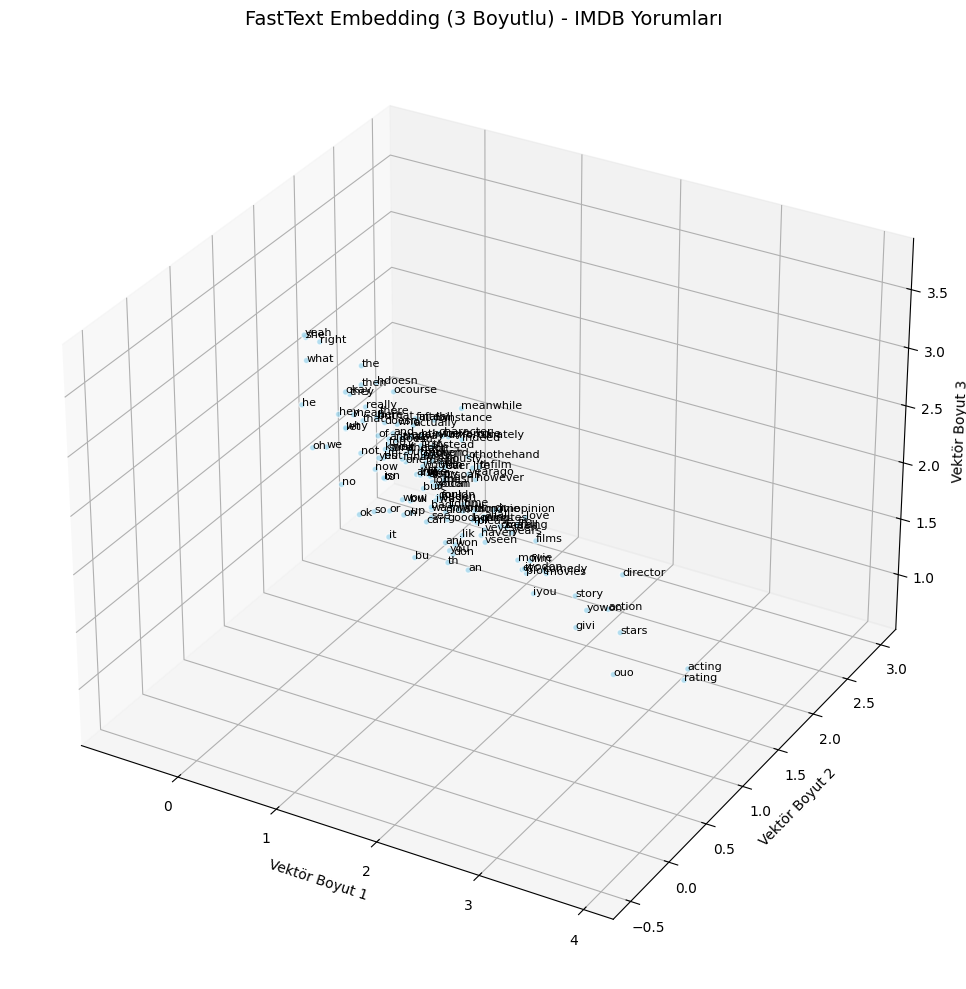

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Figür oluşturma
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Noktaların çizilmesi
ax.scatter(
    [v[0] for v in vektorler],
    [v[1] for v in vektorler],
    [v[2] for v in vektorler],
    alpha=0.6,
    c='skyblue', # Renk eklemek derinliği anlamaya yardımcı olur
    edgecolors='w'
)

# Kelime etiketlerinin eklenmesi
for i, kelime in enumerate(kelimeler):
    ax.text(vektorler[i][0], vektorler[i][1], vektorler[i][2], kelime, fontsize=8)

# Eksen ve Başlık Düzenlemeleri
plt.title("FastText Embedding (3 Boyutlu) - IMDB Yorumları", fontsize=14)

ax.set_xlabel("Vektör Boyut 1")
ax.set_ylabel("Vektör Boyut 2")
ax.set_zlabel("Vektör Boyut 3")

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px


# Veriyi DataFrame haline getirmek Plotly için en kolayıdır
df = pd.DataFrame({
    'x': [v[0] for v in vektorler],
    'y': [v[1] for v in vektorler],
    'z': [v[2] for v in vektorler],
    'kelime': kelimeler
})

fig = px.scatter_3d(df, x='x', y='y', z='z', text='kelime', title="İnteraktif FastText 3D")
fig.update_traces(textposition='top center')
fig.show()

# Görüntülerden Öznitelik Çıkartma
Çıkarılabilecek temel öznitelikler
* Renk özellikleri: RGB, HSV, renk histogramı
* Kenar ve köşe özellikleri: Sobel, Canny, Harris Corner
* Doku özellikleri: Gabor filtreleri, Local Binary Patterns
* Şekil özellikleri: Kontur momentler, objenin boyut oranları
* Bu öznitelikler bir araya gelerek görselin " parmak izi " ni oluşturur.
****
Klasik Öznitelik Çıkarma Yöntemleri
* SIFT (Scale-Invariant Feature Transform): Nesne tanımada ölçek ve döndürme farkına dayanıklı -> Görüntüdeki karakteristik noktaları bulur ve her birine benzersiz bir vektör tanımlar. Bu sayede farklı açıdan çekilmiş nesneler tanınabilir.
* SURF (Speeded-Up Robust Features): SIFT'e benzer ama daha hızlıdır. -> Temel desenleri tanımlarken integral kullanır
* HOG (Histogram of orianted Gradients): Kenar yönelimlerine dayalı öznitelikler (yönüne) çıkarır. -> Özellikle insan ve araç tespiti gibi nesne tanıma algoritmalarında
* ORB (Oriented FAST and Rotated BRIEF): Hafif, gerçek zamanlı uygulamalara uygun bir yöntem. (Fast dedektörü ile köşeleri bulur ve BRIEF algoritmasıyla bunları tanımlar.)

> Tamamı hand crofted features : Derin öğrenmeden önce insan eliyle bulunan öznitelikler.
****
Derin Öğrenme ile Otomatik Öznitelik Çıkarma
* Öznitelikleri kendi kendine öğrenir
* Alt katmanlar: Kenarlar, renk geçişler
* Orta katmanlar: Şekiller, desenler
* Üst katmanlar: anlamlı objeler (yüz, araba, kedi...)
****
içerik:
1. Renk Özellikleri: Görseldeki RGB kanal dağılımlarını renk histogramı ile çıkarma
2. Kenar Özellikleri: sobel filtresi ile yatay ve dikey kenarları tespit etme
3. Köşe özellikleri: Görseldeki belirgin köşe noktalarını bulma
4. Doku özellikler: Local binary pattarn (LBP) yöntemiyle yüzey desenlerini analiz etme


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import local_binary_pattern
from skimage.measure import moments_hu, label, regionprops
from skimage.color import rgb2gray

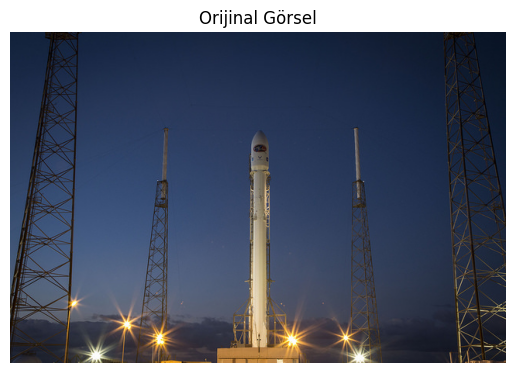

In [48]:
# hazır görüntü yükle
image = data.rocket()
plt.imshow(image)
plt.title("Orijinal Görsel")
plt.axis("off")
plt.show()

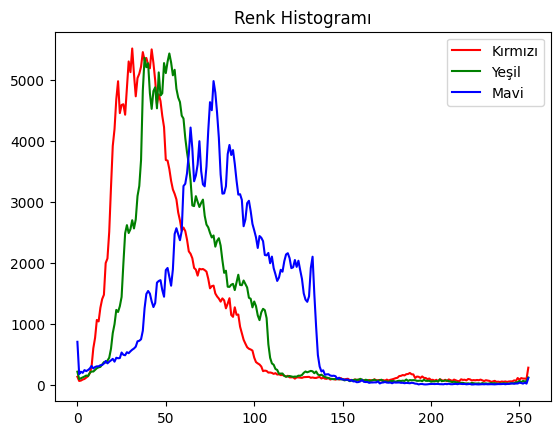

In [49]:
# renk özellikleri
# renk histogramı: R-G-B kanallarında ki renk dağılımını öznitelik olarak alır

hist_r = cv2.calcHist([image], [0], None, [256], [0,256])
hist_g = cv2.calcHist([image], [1], None, [256], [0,256])
hist_b = cv2.calcHist([image], [2], None, [256], [0,256])

plt.figure()
plt.plot(hist_r, color = "red", label = "Kırmızı")
plt.plot(hist_g, color = "green", label = "Yeşil")
plt.plot(hist_b, color = "blue", label = "Mavi")
plt.title("Renk Histogramı")
plt.legend()
plt.show()

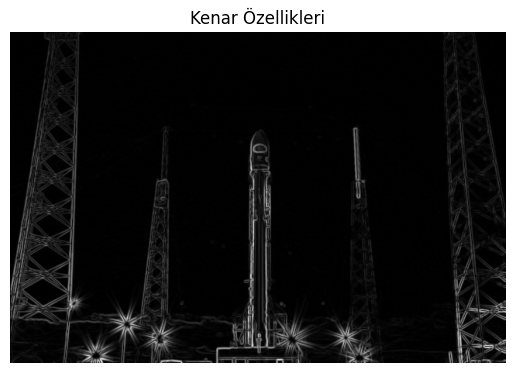

In [50]:
# Kenar Özellikleri
# sobel filtresiyle yatay ve dikey kenarları bulma

gray = rgb2gray(image)
edges_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize = 5) # x yönündeki yatay kenarları bulur
edges_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize = 5) # y yönündeki yatay kenarları bulur

edges = np.sqrt(edges_x**2 + edges_y**2) # iki yönü birleştir

plt.imshow(edges, cmap = "gray")
plt.title("Kenar Özellikleri")
plt.axis("off")
plt.show()

### Görüntüdeki 3D İllüzyonu: Sobel Operatörü

Görüntünün bir anda "3D" gibi görünmesinin sırrı aslında bir illüzyonda saklı. **Sobel operatörü**, bir resimdeki renk geçişlerini (gradyanları) hesaplayarak bize nesnelerin **derinlik ve yükseklik haritasını** çıkarır.

Senin paylaştığın o üç satır, aslında görüntünün her bir pikseline *"Yanındaki komşunla aranda ne kadar fark var?"* diye sorar. İşte bu sürecin matematiksel perde arkası:

---

 1. Yönleri Belirlemek: `edges_x` ve `edges_y`

Sobel operatörü, görüntü üzerindeki **türevi** (değişim oranını) hesaplar. Resimdeki pikselleri birer sayı tablosu olarak düşünürsek:

*   **`edges_x` (Yatay Gradyan):** Görüntüdeki **dikey kenarları** yakalar. Eğer soldan sağa doğru ani bir renk değişimi varsa (örneğin siyah bir duvardan beyaz bir kapıya geçiş), bu değer yüksek çıkar.
*   **`edges_y` (Dikey Gradyan):** Görüntüdeki **yatay kenarları** yakalar. Yukarıdan aşağıya olan değişimleri ölçer.

> **Bilgi:** Kodda kullanılan `ksize = 5`, algoritmanın ne kadar geniş bir alana bakacağını belirler. 5x5'lik bir pencereden bakmak, gürültüyü azaltır ve kenarları daha belirgin hale getirir.

---

 2. İki Dünyayı Birleştirmek: Pisagor Teoremi

Resmin "3D" hissi veren o meşhur derinliği, bu iki yönün birleştirilmesiyle oluşur. Kodundaki şu satır:
`edges = np.sqrt(edges_x**2 + edges_y**2)`

Aslında bildiğimiz **Öklid mesafesi** veya **Pisagor teoremi**dir. Her bir piksel için toplam gradyan büyüklüğünü ($G$) şu formülle hesaplar:

$$G = \sqrt{G_x^2 + G_y^2}$$

**Bu işlem sonucunda:**
*   Değişimin olmadığı **düz alanlar** 0 (siyah) olur.
*   Değişimin (kenarın) çok **keskin olduğu yerler** yüksek değerler (beyaz/parlak) alır.

---

 3. Neden 3D Gibi Görünüyor?

İnsan beyni, gölgeleri ve ışık değişimlerini derinlik olarak algılamaya programlıdır. Sobel filtresi uygulandığında iki ana olay gerçekleşir:

1.  **Işık Yanılması:** Kenarların bir tarafı çok parlak, diğer tarafı karanlık kaldığı için beyin bunu bir **"kabartma" (relief)** gibi algılar.
2.  **Vektörel Büyüklük:** `np.sqrt` işlemiyle elde edilen değerler, aslında o noktadaki **"eğimi"** temsil eder.

---

> **Özetle:** Resim aslında hala 2D. Ancak sen bu kodla her pikselin **"ne kadar dik bir yokuşta"** olduğunu hesaplayıp bunu bir parlaklık değeri olarak atadığın için, gözün onu bir topografik harita gibi algılıyor.

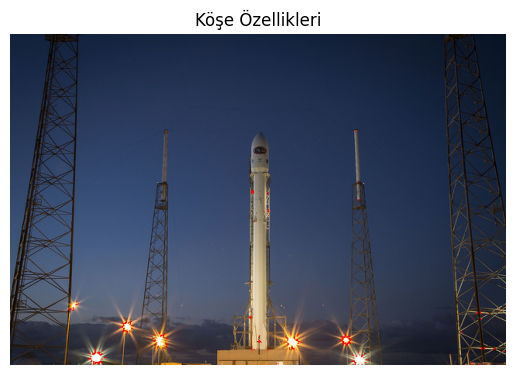

In [51]:
# Köşe özellikleri

gray_cv = np.float32(rgb2gray(image))

dst = cv2.cornerHarris(gray_cv, blockSize = 4, ksize = 5, k = 0.2) # k -> treshold

# gürültüyü azaltmak için köşe haritasını genişlet
sdt = cv2.dilate(dst, None)

# daha yüksek eşik değeri
threshold = 0.03*dst.max()
corner_mask = dst > threshold

#köşeleri renklendir
image_corners = image.copy()
image_corners[corner_mask] = [255, 0, 0] # kırmızı köşeler

plt.imshow(image_corners)
plt.title("Köşe Özellikleri")
plt.axis("off")
plt.show()

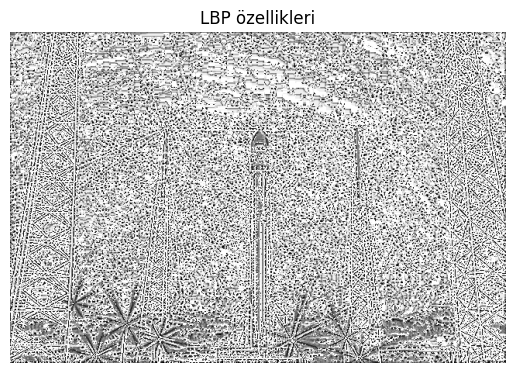

In [58]:
# Doku Özellikleri
# local_binary_pattern
radius = 2 # komşuluk yarıçapı
n_points = 8 * radius # komşu sayısı
lbp = local_binary_pattern(gray, n_points, radius,  method = "uniform")

# görselleştir
plt.imshow(lbp, cmap ="gray")
plt.title("LBP özellikleri")
plt.axis("off")
plt.show()

# PCA
Yüksek boyutlu veriyi daha az boyutlu bir uzaya indirgeme
* Boyut indirgeme yaparken en fazla bilgiyi korumayı hedefler
* Bilgi -> verinin varyansı (değişkenliği)
* Verideki değişkenler arasındaki ilişkileri ortaya çıkarır
Amaç: karmaşık veriyi özetleyi, görselleştirmeyi ve öğrenmeyi kolaylaştırmak.
****
Nasıl çalışır?
1. Verideki en fazla varyansı açıklayan doğrultuları bulur.
2. Bu doğrultular "temep bileşenler (principal components)" olarak adlandırılır.
3. Her bileşen verinin yeni bir ekseni olur.
4. Bileşenler birbirinden bağımsızdır.
-> PCA sonrası elde edilen bileşenler birbirleriyle korelasyon göstermezler. Bu durum bazı makine öğrenmesi modellerinde performans artışı sağlar.
****
PCA uygulama adımları:
1. Veriyi standarize etme.
2. Kovaryans matrisi oluşturulur.
3. Özdeğer ve özvektörler hesaplanır.
4. En yüksek değerlere sahip bileşenler seçilir.
5. Veriyi bu yeni bileşenler ile yansıtma
*****
Avantajları:
* Boyutu ve gürültüyü azaltır
* Hesaplama maliyetini düşürür
* Görselleştirmeyi kolaylaştırır
* Overfitting önler
Dezavantajları:
* Yorumlaması zor
* doğrusal ilişkileri temel alır, doğrusal olmayan ilişkileri yakalayamaz
* ölçek farklılıklarına duyarlıdır
****
Kullanımı:
* Görsel sıkıştırma
* Öznitelik indirgeme
* Gürültü azaltma
* Veriyi 2D/3D uzayda görselleştirilebilir
* MÖ öncesinde boyut azaltma
* Anomali tespiti




### PCA ile 2d/3d görselleştirme yapma
* iris verisi ile PCA kullanarak 4 boyuttan 2 yapma
* sütunları 2d'de görselleştirme

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA


In [61]:
# 1. iris veri setini yükleme
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [81]:
# 2. x ve y tanımlama
x = iris.data
y = iris.target

In [63]:
# 3. PCA ile dimension reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x)

In [65]:
X_pca

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

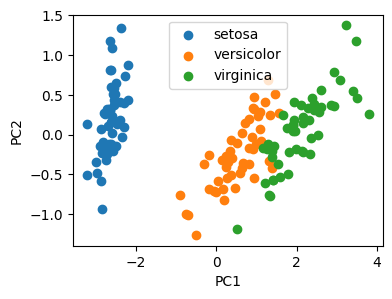

In [70]:
# 2D Görselleştirme
plt.figure(figsize=(4,3))
for i in range(len(iris.target_names)):
  plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label = iris.target_names[i] )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

In [82]:
# 3D görselleştirme
pca = PCA(n_components=3)
X_pca = pca.fit_transform(x)

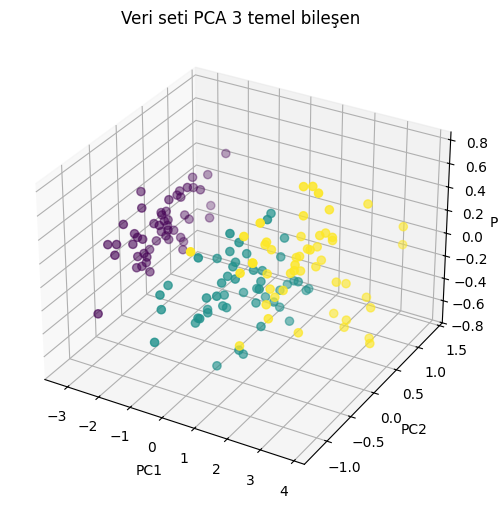

In [84]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection = "3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=y, s = 35)

ax.set_title("Veri seti PCA 3 temel bileşen")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()